In [1]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np
import random
import cv2
import os

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parthdubey118","key":"da25a2812dc7fd3b65705347aa75f05d"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.67GB/s]


In [5]:
!unzip -q fer2013.zip -d dataset

# Visualizing Data

In [6]:
train_path = "/content/dataset/train"
test_path = "/content/dataset/test"

Classes found: ['fear', 'happy', 'sad', 'angry', 'disgust', 'surprise', 'neutral']


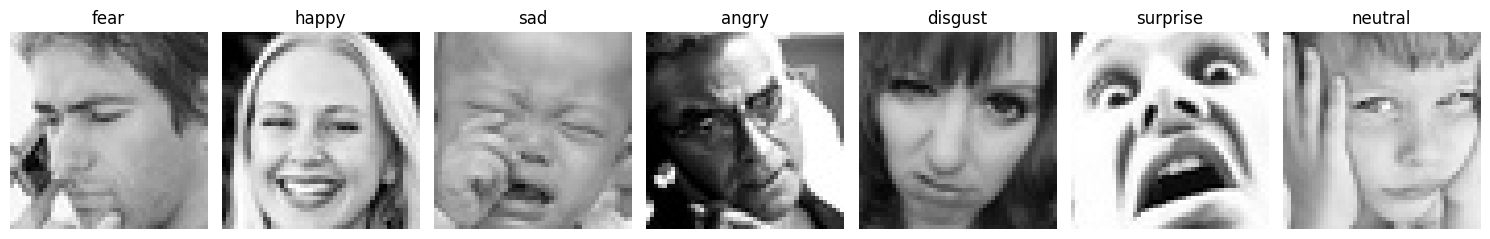

In [7]:
classes = os.listdir(train_path)
print("Classes found:", classes)

plt.figure(figsize=(15, 5))
for i, emotion in enumerate(classes):
    emotion_path = os.path.join(train_path, emotion)
    random_img = random.choice(os.listdir(emotion_path))
    img_path = os.path.join(emotion_path, random_img)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Image parameters
IMG_SIZE = (48, 48)
BATCH_SIZE = 128
EPOCHS = 100
NUM_CLASSES = 7

In [9]:
# Data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

In [10]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
# Loading training and validation data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 22968 images belonging to 7 classes.


In [12]:
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 5741 images belonging to 7 classes.


In [13]:
# Loading test data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

Found 7178 images belonging to 7 classes.


### Visualizing original vs. augmented images

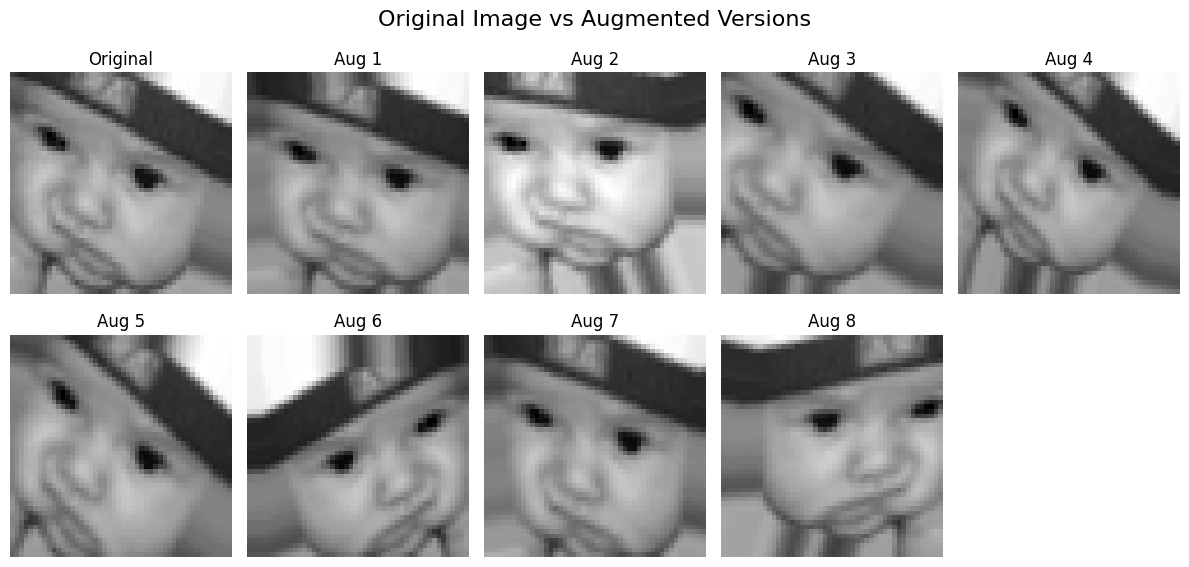

In [14]:
# Take one image
images, labels = next(train_generator)
img = images[0]

# Plot original + augmented versions
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(img.reshape(48,48), cmap='gray')
plt.title("Original")
plt.axis('off')

# Show 8 augmented versions
for i in range(8):
    augmented_img = train_datagen.random_transform(img)
    plt.subplot(2, 5, i + 2)
    plt.imshow(augmented_img.reshape(48,48), cmap='gray')
    plt.title(f"Aug {i+1}")
    plt.axis('off')

plt.suptitle("Original Image vs Augmented Versions", fontsize=16)
plt.tight_layout()
plt.show()

# Building the CNN Model

A deep CNN architecture with Batch Normalization, Dropout, and the Adam optimizer.

In [15]:
# Building a deeper CNN model
model = Sequential([
    # Block 1
    Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 4
    Conv2D(512, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(512, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Dense layers
    Flatten(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,946,055 (37.94 MB)

 Trainable params: 9,939,143 (37.91 MB)

 Non-trainable params: 6,912 (27.00 KB)

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

In [18]:
# We use class weights to address class imbalance since some classes have fewer samples.

# 1. Get the class indices and counts from the training generator
class_labels = train_generator.classes
num_classes = train_generator.num_classes

# 2. Compute class weights
class_weights_array = class_weight.compute_class_weight(
    "balanced",
    classes = np.unique(class_labels),
    y = class_labels
)

class_weights = dict(enumerate(class_weights_array))
print("Calculated Class Weights:", class_weights)

Calculated Class Weights: {0: np.float64(1.0266404434114071), 1: np.float64(9.401555464592715), 2: np.float64(1.0009587727708533), 3: np.float64(0.5684585684585685), 4: np.float64(0.826068191627104), 5: np.float64(0.8491570541259982), 6: np.float64(1.2933160650937552)}


# Model Training
Using EarlyStopping, ReduceLROnPlateau, and class weights to handle imbalanced data.

In [19]:
# Training the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight = class_weights,
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


180/180 ━━━━━━━━━━━━━━━━━━━━ 73s 261ms/step - accuracy: 0.1560 - loss: 2.8746 - val_accuracy: 0.2292 - val_loss: 2.0440 - learning_rate: 0.0010
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step - accuracy: 0.1650 - loss: 2.2283 - val_accuracy: 0.1355 - val_loss: 1.9769 - learning_rate: 0.0010
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 139ms/step - accuracy: 0.1897 - loss: 2.0276 - val_accuracy: 0.2008 - val_loss: 1.9069 - learning_rate: 0.0010
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 139ms/step - accuracy: 0.2165 - loss: 1.9365 - val_accuracy: 0.1524 - val_loss: 1.9770 - learning_rate: 0.0010
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step - accuracy: 0.2534 - loss: 1.8779 - val_accuracy: 0.3137 - val_loss: 1.7865 - learning_rate: 0.0010
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step - accuracy: 0.3170 - loss: 1.7736 - val_accuracy: 0.2656 - val_loss: 1.8499 - learning_rate: 0.0010
Epoch 7/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step - accuracy: 0.3726 -

# Model Evaluation

In [20]:
# Evaluating on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6367 - loss: 1.0230
Test Accuracy: 0.6619


In [21]:
# Predictions and metrics
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred_classes, target_names=train_generator.class_indices.keys()))

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step
              precision    recall  f1-score   support

       angry       0.56      0.64      0.60       958
     disgust       0.55      0.61      0.58       111
        fear       0.51      0.44      0.47      1024
       happy       0.92      0.83      0.87      1774
     neutral       0.58      0.69      0.63      1233
         sad       0.57      0.49      0.53      1247
    surprise       0.73      0.83      0.77       831

    accuracy                           0.66      7178
   macro avg       0.63      0.65      0.64      7178
weighted avg       0.67      0.66      0.66      7178



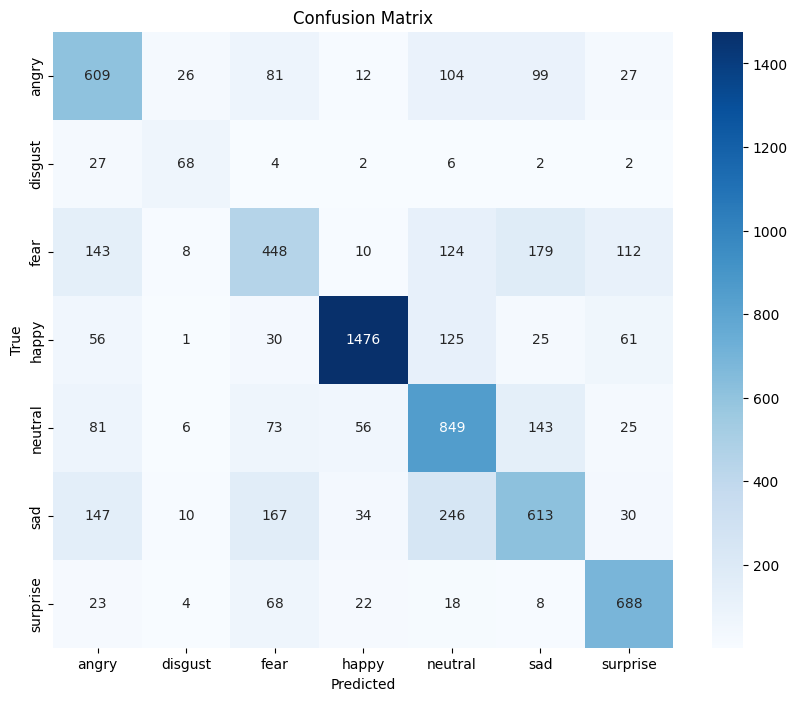

In [22]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

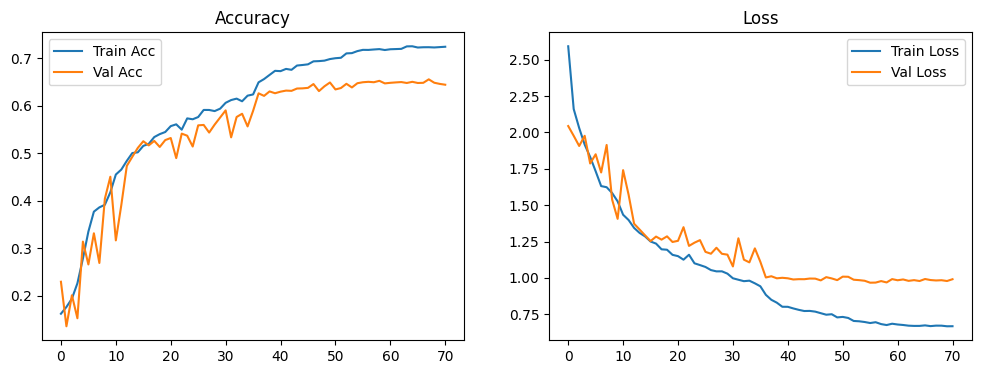

In [23]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Predictions Visualization

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


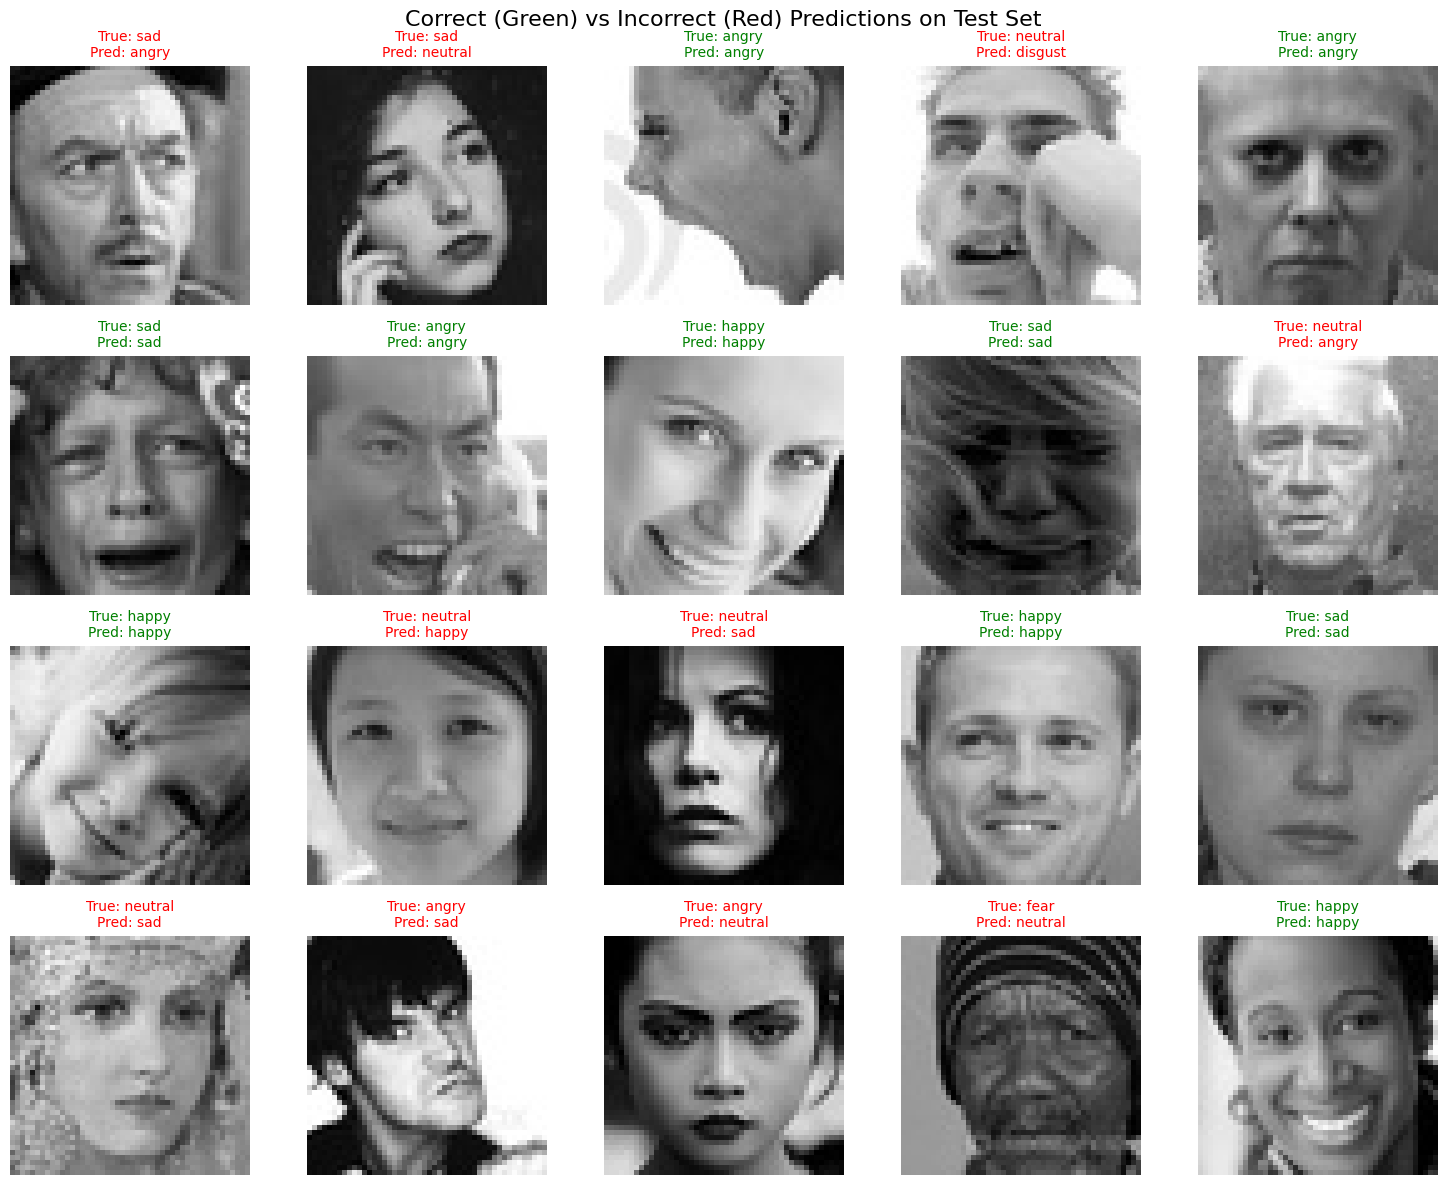

In [24]:
# Visualizing correct & wrong predictions

# File paths from test generator
filenames = test_generator.filenames
n_samples = len(filenames)
n_display = 20  # Number of images to show (mix of correct and wrong)

# True labels and predictions
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

# Correct and incorrect indices
correct_idx = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

# Shuffling & selecting some from each
np.random.shuffle(correct_idx)
np.random.shuffle(incorrect_idx)

selected_correct = correct_idx[:n_display // 2]
selected_incorrect = incorrect_idx[:min(len(incorrect_idx), n_display // 2)]

selected_idx = np.concatenate([selected_correct, selected_incorrect])
np.random.shuffle(selected_idx)

# Class names
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(15, 3 * (n_display // 5 + 1)))
for i, idx in enumerate(selected_idx[:n_display]):
    # Load image
    img_path = os.path.join(test_path, filenames[idx])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)  # Ensure same size

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    correct = y_true[idx] == y_pred[idx]

    # Title color: green for correct, red for wrong
    color = 'green' if correct else 'red'
    title = f"True: {true_label}\nPred: {pred_label}"

    plt.subplot(n_display // 5 + 1, 5, i + 1)
    plt.imshow(img)
    plt.title(title, color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Correct (Green) vs Incorrect (Red) Predictions on Test Set", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
# Save the model
model.save("emotion_recognition_model.keras")
print("Model saved successfully!")

Model saved successfully!
